In [4]:
import warnings
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from IPython.display import Markdown, display

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    roc_curve, confusion_matrix, classification_report, ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42
DATA_DIR = Path(r"E:\Credit Risk Assessment System\dataset\processed_models")
PROJECT_DIR = Path(r"E:\Credit Risk Assessment System")

In [5]:
try:
    X_train = pd.read_csv(DATA_DIR / "X_train_scaled.csv")
    X_test = pd.read_csv(DATA_DIR / "X_test_scaled.csv")
    y_train = pd.read_csv(DATA_DIR / "y_train.csv").squeeze()
    y_test = pd.read_csv(DATA_DIR / "y_test.csv").squeeze()
except FileNotFoundError as exc:
    raise FileNotFoundError("Run 05_Data_Preprocessing_for_Modeling.ipynb first") from exc

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Feature count:", X_train.shape[1])
display(pd.DataFrame({
    "train_%": y_train.value_counts(normalize=True).mul(100).round(2),
    "test_%": y_test.value_counts(normalize=True).mul(100).round(2),
}))

Train: (452296, 149) Test: (61503, 149)
Feature count: 149


,train_%,test_%
TARGET,,
0,50.0,91.93
1,50.0,8.07


In [6]:
model = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000,
    class_weight="balanced",
    solver="lbfgs",
)
print(model)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)


In [7]:
start = time.time()
model.fit(X_train, y_train)
training_time = time.time() - start

print(f"Model trained in {training_time:.2f} seconds")

Model trained in 6.03 seconds


In [8]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)
y_test_proba = model.predict_proba(X_test)[:, 1]

print("Sample predicted classes:", y_test_pred[:5])
print("Sample predicted probabilities (TARGET=1):", y_test_proba[:5].round(3))

Sample predicted classes: [0 0 1 1 1]
Sample predicted probabilities (TARGET=1): [0.4   0.307 0.829 0.577 0.508]


In [9]:
def evaluate(y_true, y_pred, y_proba=None) -> dict:
    """Compute standard classification metrics."""
    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
    }
    if y_proba is not None:
        metrics["ROC-AUC"] = roc_auc_score(y_true, y_proba)
    return metrics

test_metrics = evaluate(y_test, y_test_pred, y_test_proba)
metrics_df = pd.DataFrame(test_metrics.items(), columns=["Metric", "Value"])
metrics_df["Value"] = metrics_df["Value"].round(4)
display(metrics_df)

print(f"Observation: Recall ({test_metrics['Recall']:.2f}) matters most here — "
      f"missing an actual defaulter (false negative) is typically costlier to a "
      f"bank than flagging a safe applicant for review (false positive).")

,Metric,Value
0,Accuracy,0.6944
1,Precision,0.1628
2,Recall,0.6725
3,F1 Score,0.2621
4,ROC-AUC,0.7465


Observation: Recall (0.67) matters most here — missing an actual defaulter (false negative) is typically costlier to a bank than flagging a safe applicant for review (false positive).


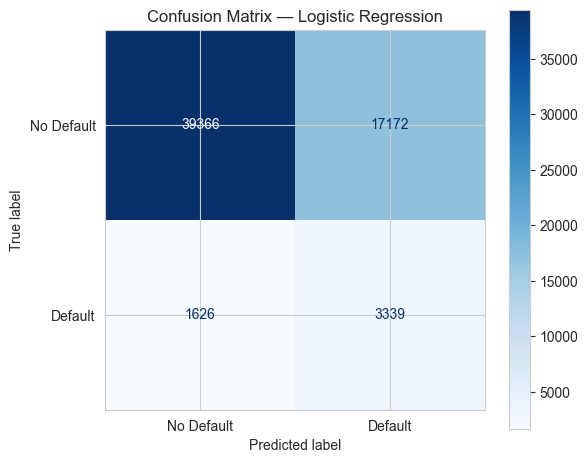

True Negatives (correctly predicted safe): 39366
False Positives (safe applicant flagged as risky): 17172
False Negatives (defaulter missed — costliest error for a bank): 1626
True Positives (correctly predicted default): 3339


In [10]:
cm = confusion_matrix(y_test, y_test_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=["No Default", "Default"]).plot(ax=ax, cmap="Blues")
ax.set_title("Confusion Matrix — Logistic Regression")
plt.tight_layout()
plt.show()

print(f"True Negatives (correctly predicted safe): {tn}")
print(f"False Positives (safe applicant flagged as risky): {fp}")
print(f"False Negatives (defaulter missed — costliest error for a bank): {fn}")
print(f"True Positives (correctly predicted default): {tp}")

In [11]:
report = classification_report(y_test, y_test_pred, target_names=["No Default", "Default"])
print(report)

              precision    recall  f1-score   support

  No Default       0.96      0.70      0.81     56538
     Default       0.16      0.67      0.26      4965

    accuracy                           0.69     61503
   macro avg       0.56      0.68      0.53     61503
weighted avg       0.90      0.69      0.76     61503



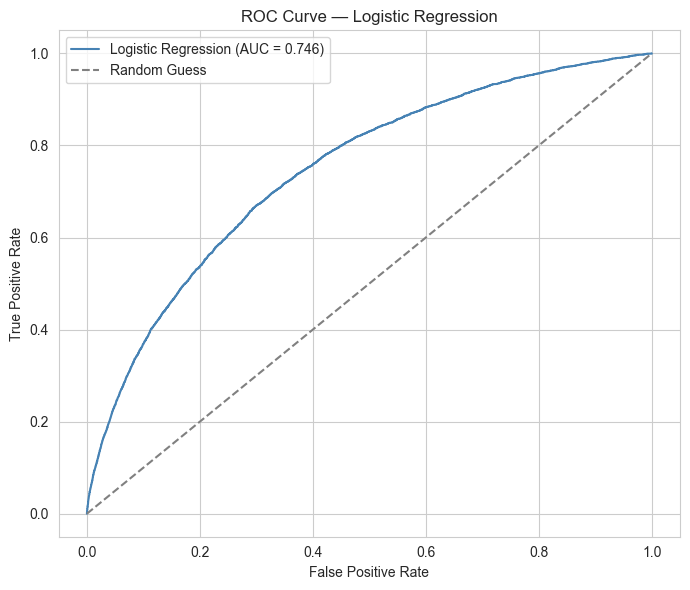

In [12]:
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
auc = roc_auc_score(y_test, y_test_proba)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.3f})", color="steelblue")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
ax.set_title("ROC Curve — Logistic Regression")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()
plt.tight_layout()
plt.show()

In [13]:
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_[0],
})
coef_df["Absolute Coefficient"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values("Absolute Coefficient", ascending=False)

top_positive = coef_df[coef_df["Coefficient"] > 0].head(20)
top_negative = coef_df[coef_df["Coefficient"] < 0].head(20)

print("Top 20 features that INCREASE default probability:")
display(top_positive)
print("Top 20 features that REDUCE default probability:")
display(top_negative)

Top 20 features that INCREASE default probability:


,Feature,Coefficient,Absolute Coefficient
127,num__AMT_CREDIT,0.365996,0.365996
140,num__BASEMENTAREA_MEDI,0.204013,0.204013
142,num__ANNUITY_INCOME_RATIO,0.188893,0.188893
115,num__REGION_RATING_CLIENT_W_CITY,0.172751,0.172751
138,num__LIVINGAREA_AVG,0.157110,0.157110
147,num__LOG_AMT_INCOME_TOTAL,0.123847,0.123847
130,num__APARTMENTS_AVG,0.120592,0.120592
112,num__DAYS_EMPLOYED,0.095088,0.095088
20,cat__CODE_GENDER_M,0.087781,0.087781
123,num__FLAG_DOCUMENT_3,0.084498,0.084498


Top 20 features that REDUCE default probability:


,Feature,Coefficient,Absolute Coefficient
122,num__AMT_GOODS_PRICE,-0.585895,0.585895
108,num__EXT_SOURCE_3,-0.556807,0.556807
109,num__EXT_SOURCE_2,-0.474854,0.474854
139,num__BASEMENTAREA_AVG,-0.245869,0.245869
107,num__EXT_SOURCE_1,-0.194759,0.194759
119,num__ANNUITY_CREDIT_RATIO,-0.104535,0.104535
137,num__LIVINGAREA_MEDI,-0.102457,0.102457
19,cat__CODE_GENDER_F,-0.087685,0.087685
117,num__REGION_RATING_CLIENT,-0.081135,0.081135
132,num__APARTMENTS_MODE,-0.080707,0.080707


In [14]:
model_dir = PROJECT_DIR / "models"
model_dir.mkdir(parents=True, exist_ok=True)

try:
    joblib.dump(model, model_dir / "logistic_regression_model.pkl")
    print("Model saved to", model_dir / "logistic_regression_model.pkl")
except OSError as exc:
    raise OSError(f"Could not save model to {model_dir}") from exc

Model saved to E:\Credit Risk Assessment System\models\logistic_regression_model.pkl


In [15]:
summary_table = pd.DataFrame([
    {"Metric": "Accuracy", "Value": round(test_metrics["Accuracy"], 4),
     "Interpretation": "Overall correct-prediction rate — least informative here given class imbalance"},
    {"Metric": "Precision", "Value": round(test_metrics["Precision"], 4),
     "Interpretation": "Of applicants flagged risky, how many actually default"},
    {"Metric": "Recall", "Value": round(test_metrics["Recall"], 4),
     "Interpretation": "Of actual defaulters, how many the model caught"},
    {"Metric": "F1 Score", "Value": round(test_metrics["F1 Score"], 4),
     "Interpretation": "Balance of precision and recall"},
    {"Metric": "ROC-AUC", "Value": round(test_metrics["ROC-AUC"], 4),
     "Interpretation": "Ability to rank defaulters above non-defaulters across all thresholds"},
    {"Metric": "Training Time (s)", "Value": round(training_time, 2),
     "Interpretation": "Fast — expected for a linear model at this feature count"},
])
display(summary_table)

conclusion = f"""
Logistic Regression is **unlikely to outperform tree-based models**
(Random Forest, XGBoost) on this dataset, since credit risk features
plausibly interact non-linearly (e.g. income relative to employment
length). Its value here is as an **interpretable baseline** — any
tree-based model built next should clearly beat ROC-AUC={test_metrics['ROC-AUC']:.4f}
to justify its added complexity.
"""
display(Markdown(conclusion))

,Metric,Value,Interpretation
0,Accuracy,0.6944,Overall correct-prediction rate — least inform...
1,Precision,0.1628,"Of applicants flagged risky, how many actually..."
2,Recall,0.6725,"Of actual defaulters, how many the model caught"
3,F1 Score,0.2621,Balance of precision and recall
4,ROC-AUC,0.7465,Ability to rank defaulters above non-defaulter...
5,Training Time (s),6.0300,Fast — expected for a linear model at this fea...



Logistic Regression is **unlikely to outperform tree-based models**
(Random Forest, XGBoost) on this dataset, since credit risk features
plausibly interact non-linearly (e.g. income relative to employment
length). Its value here is as an **interpretable baseline** — any
tree-based model built next should clearly beat ROC-AUC=0.7465
to justify its added complexity.
